In [8]:
library(dplyr)


In [9]:
file_path <- "../data/global_air_quality_dataset.csv"

if(file.exists(file_path)) {
  air_quality <- read.csv(file_path)
  head(air_quality)
} else {
  print("Can't fined the file. Please check the path.")
}

,Date,City,Country,AQI,PM2.5....g.m...,PM10....g.m...,NO2..ppb.,SO2..ppb.,CO..ppm.,O3..ppb.,Temperature....C.,Humidity....,Wind.Speed..m.s.
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
2,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
3,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
4,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
5,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3
6,2024-01-01,Paris,France,170,217.6,278.0,21.7,45.2,1.77,125.2,37.4,67,1.4


In [10]:
summary(air_quality)

     Date               City             Country               AQI       
 Length:3660        Length:3660        Length:3660        Min.   : 30.0  
 Class :character   Class :character   Class :character   1st Qu.: 96.0  
 Mode  :character   Mode  :character   Mode  :character   Median :165.0  
                                                          Mean   :164.6  
                                                          3rd Qu.:233.0  
                                                          Max.   :300.0  
 PM2.5....g.m... PM10....g.m...    NO2..ppb.        SO2..ppb.    
 Min.   :  5.1   Min.   : 10.0   Min.   :  5.10   Min.   : 2.00  
 1st Qu.: 63.7   1st Qu.: 82.2   1st Qu.: 29.18   1st Qu.:13.70  
 Median :125.8   Median :152.6   Median : 52.80   Median :26.20  
 Mean   :126.4   Mean   :154.8   Mean   : 52.96   Mean   :25.94  
 3rd Qu.:187.0   3rd Qu.:227.6   3rd Qu.: 76.70   3rd Qu.:38.20  
 Max.   :250.0   Max.   :300.0   Max.   :100.00   Max.   :50.00  
    CO..ppm.        

In [11]:
str(air_quality)

'data.frame':	3660 obs. of  13 variables:
 $ Date             : chr  "2024-01-01" "2024-01-01" "2024-01-01" "2024-01-01" ...
 $ City             : chr  "New York" "Los Angeles" "London" "Beijing" ...
 $ Country          : chr  "USA" "USA" "UK" "China" ...
 $ AQI              : int  38 280 117 197 187 170 177 164 123 241 ...
 $ PM2.5....g.m...  : num  120 38.4 168.1 96.8 76.2 ...
 $ PM10....g.m...   : num  182.9 46.9 34.3 35.4 226.8 ...
 $ NO2..ppb.        : num  24.3 41.8 81.5 18.5 46.9 21.7 9.5 26.1 6.4 74.4 ...
 $ SO2..ppb.        : num  26 34.7 8.2 39.4 17.2 45.2 46 18.4 19.7 16.4 ...
 $ CO..ppm.         : num  9.1 3.78 3.67 9.51 1.02 1.77 3.75 5.48 1.08 1.25 ...
 $ O3..ppb.         : num  153.3 190.7 105.4 92.8 68.4 ...
 $ Temperature....C.: num  18.6 -2.2 36.3 29.9 9.9 37.4 15.5 -6.8 7.1 37.5 ...
 $ Humidity....     : int  40 59 62 32 55 67 43 81 10 23 ...
 $ Wind.Speed..m.s. : num  13.2 9.5 3.4 1.8 3.3 1.4 1.8 14.3 5.3 14 ...


In [12]:
#Data cleaning
colnames(air_quality) <- c(
  "Date",
  "City",
  "Country",
  "AQI",
  "PM2.5",
  "PM10",
  "NO2",
  "SO2",
  "CO",
  "O3",
  "Temperature",
  "Humidity",
  "WindSpeed"
)

print("Missing values per column:")
print(colSums(is.na(air_quality)))

air_quality$Date <- as.Date(air_quality$Date)

[1] "Missing values per column:"
       Date        City     Country         AQI       PM2.5        PM10 
          0           0           0           0           0           0 
        NO2         SO2          CO          O3 Temperature    Humidity 
          0           0           0           0           0           0 
  WindSpeed 
          0 


In [13]:
air_quality_clean <- air_quality 
head(air_quality_clean)

,Date,City,Country,AQI,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,WindSpeed
,<date>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
2,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
3,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
4,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
5,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3
6,2024-01-01,Paris,France,170,217.6,278.0,21.7,45.2,1.77,125.2,37.4,67,1.4


In [44]:
png("qq_plot_final_3.png", width = 900, height = 700) # Reduced width makes text relatively larger

# par(mar) adds extra space around the edges so the large labels aren't cut off
par(mar = c(6, 6, 5, 2) + 0.1) 

plot(final_model, 
     which = 2, 
     main = "QQ Plot of Residuals for PM2.5 Model",
     cex.main = 2.5,  # Much larger Title
     cex.lab = 2.2,   # Much larger Axis Labels (Theoretical Quantiles / Standardized Residuals)
     cex.axis = 1.8,  # Much larger axis numbers (-2, 0, 2)
     cex = 1.5)       # Larger dots

dev.off()

pdf 
  2

In [32]:
# Save QQ plot as PNG
png("qq_plot_residuals.png", width = 800, height = 600)
final_model <- lm(PM2.5 ~ SO2 + CO + O3, data = air_quality_clean)
plot(final_model, which = 2, main = "QQ Plot of Residuals for PM2.5 Model")
dev.off()

pdf 
  2

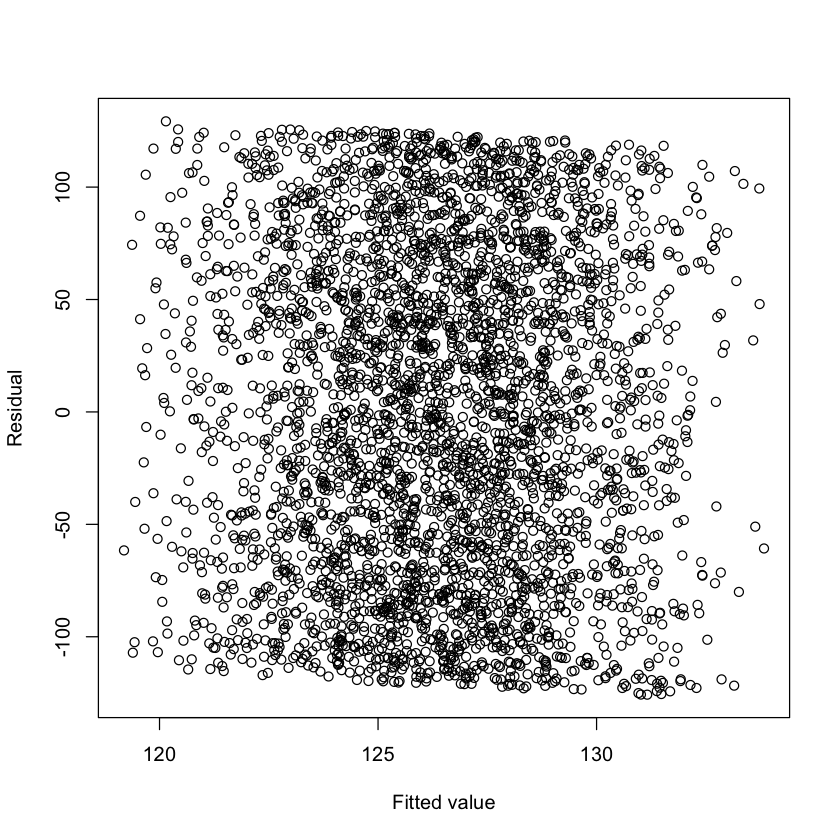

In [39]:
model <- lm(air_quality_clean$PM2 ~ air_quality_clean$SO2 + air_quality_clean$CO + air_quality_clean$O3, data = air_quality_clean)

plot(model$fitted.values, model$residuals, xlab="Fitted value", ylab="Residual")

In [40]:
# 1. Open the file device
png("residuals_vs_fitted_final.png", width = 900, height = 700)

# 2. Adjust margins slightly so large labels aren't cut off
par(mar = c(5, 5, 4, 2) + 0.1)

# Note: Using PM2.5 as per your dataset column name
model <- lm(PM2.5 ~ SO2 + CO + O3, data = air_quality_clean)

# 3. Create the plot with readable sizes
plot(model$fitted.values, 
     model$residuals, 
     main = "Residuals vs Fitted Values",
     xlab = "Fitted Values", 
     ylab = "Residuals",
     cex.main = 1.8,  # Increases Title size
     cex.lab = 1.5,   # Increases "Fitted Values" and "Residuals" labels
     cex.axis = 1.3,  # Increases axis numbers
     cex = 1.2,       # Increases size of the dots
     pch = 20,        # Uses solid circles (cleaner for reports)
     col = rgb(0, 0, 1, 0.3)) # Blue with 30% transparency helps show density

# 4. Add a horizontal line at 0 (Essential for residual plots)
abline(h = 0, col = "red", lwd = 2, lty = 2)

# 5. Close the device
dev.off()

pdf 
  2

In [45]:
# 1. Open the file device
png("residuals_vs_fitted_final_v2.png", width = 900, height = 700)

# 2. Increase margins significantly (bottom, left, top, right)
# This prevents the larger labels from being clipped
par(mar = c(6, 6, 5, 2) + 0.1)

# Ensure the model is defined
model <- lm(PM2.5 ~ SO2 + CO + O3, data = air_quality_clean)

# 3. Create the plot with "Ultra-Readable" sizes
plot(model$fitted.values, 
     model$residuals, 
     main = "Residuals vs Fitted Values",
     xlab = "Fitted Values", 
     ylab = "Residuals",
     cex.main = 2.5,  # Matches the Q-Q plot title size
     cex.lab = 2.2,   # Matches the Q-Q plot label size
     cex.axis = 1.8,  # Matches the Q-Q plot axis number size
     cex = 1.5,       # Slightly larger dots for better visibility
     pch = 20,        
     col = rgb(0, 0, 1, 0.3)) 

# 4. Add the horizontal line at 0 (Essential for diagnostics)
abline(h = 0, col = "red", lwd = 3, lty = 2) # Increased line width to 3

# 5. Close the device
dev.off()

pdf 
  2

In [43]:
# 1. Open the file device
png("linear_regression_fit.png", width = 900, height = 700)

# 2. Adjust margins for large labels
par(mar = c(5, 5, 4, 2) + 0.1)

# 3. Ensure the model is fitted
model_multi <- lm(PM2.5 ~ CO + O3 + SO2, data = air_quality_clean)

# 4. Plot Observed vs. Predicted
# X-axis: The values the model predicts (Fitted)
# Y-axis: The actual values from the dataset (Observed)
plot(model_multi$fitted.values, 
     air_quality_clean$PM2.5,
     main = "Multiple Regression:PM2.5 vs CO, O3, SO2",
     xlab = "Predicted PM2.5 (ug/m3)",
     ylab = "Observed PM2.5 (ug/m3)",
     cex.main = 1.8,  # Large Title
     cex.lab = 1.5,   # Large Axis Labels
     cex.axis = 1.3,  # Large Numbers
     pch = 20,        # Solid circles
     col = rgb(0.1, 0.5, 0.8, 0.3)) # Transparent blue

# 5. Add the 1:1 Identity Line (Perfect fit line)
# In a perfect model, all points would sit on this line
abline(0, 1, col = "red", lwd = 3, lty = 2)

# 6. Close the device
dev.off()

pdf 
  2